<a href="https://colab.research.google.com/github/adrpage/bioinformatics-portfolio/blob/main/binary_disease_classification_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Table of Contents**
*   Importing libraries
*   Loading datasets
*   Data exploration
*   Data preprocessing
*   Multiple model comparisons
*   Final model selection
*   Final model training
*   Final model optimisation and evaluation
*   Final model deployment - hidden test
*   References and resources

Submitted by 2712255 / assessment for BIOLM0050 ML challenge

References used will be indicated by square-bracketed numbers.

Edit 16/05/26:
This was originally submitted for my Practical Bioinformatics and Machine Learning module during my MSc Bioinformatics course at the University of Bristol; April 2025/26.

The context was to design an algorithm that could rise to the challenge of predicting whether a disease was driven by majority germline mutations, or inheritable (1), or somatic mutations, ergo not inheritable (0). The dataset was somewhat imbalanced (roughly 1:5).

To address this challenge, I tested several models appropriate for a binary classification problem using stratified cross validation, ensuring that the models accounted for the imbalance, and settled on using XGBoost. I split the dataset into a training set and a validation set and used threshold tuning based on the validation set. Overall my model received a mark of 83%.


# **Importing libraries**

In [ ]:
# Data handling and visualisation libraries
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

# Model metrics libraries
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score, precision_recall_curve

# Model libraries
from sklearn.linear_model import LogisticRegression # Scikit-learn logistic regression model
from sklearn.ensemble import RandomForestClassifier # Scikit-learn random forest classifier model
from sklearn.ensemble import GradientBoostingClassifier # Scikit-learn gradient boosting model
from xgboost import XGBClassifier # XGBoost gradient boosting model

# **Loading datasets**

In [ ]:
# @title Download hidden test dataset
file_id = '1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS'
gdown.download(id=file_id,  quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS
To: /content/test.csv
100%|██████████| 12.5M/12.5M [00:00<00:00, 282MB/s]


'test.csv'

In [ ]:
# @title Download training dataset
file_id ='13CxaCVT-V0M6DZuq38p38U_FE50rxXnN'
gdown.download(id=file_id,  quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN
From (redirected): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN&confirm=t&uuid=b43da8d7-23a9-43a5-b3a8-0dd6855416e9
To: /content/train.csv
100%|██████████| 168M/168M [00:01<00:00, 154MB/s]


'train.csv'

In [ ]:
# @title Load training and hidden test datasets to dataframes
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
# Ensure ID column is kept as an index
train_df.set_index("ID", inplace=True)
test_df.set_index("ID", inplace=True)

# **Data exploration**

As is good practice when presented with new data that will undergo any kind of statistical analysis, exploration will be conducted to gain an overview of its structure.

In [ ]:
# @title Examine training dataset using head()
print("Training dataset structure:")
print(train_df.head())

Training dataset structure:
    disease  rep  num_genes     emb_0     emb_1     emb_2     emb_3     emb_4  \
ID                                                                              
0         0    3      0.005  0.004273  0.023922  0.004779 -0.006661 -0.021735   
1         1    5      0.006 -0.025024 -0.022999  0.002726 -0.003353  0.009228   
2         1    1      0.006 -0.028817  0.028247  0.013252 -0.010952 -0.014338   
3         1    1      0.006 -0.000204 -0.012802  0.012755  0.007765 -0.019451   
4         1    2      0.004  0.017057  0.017862  0.036861 -0.004437 -0.041073   

       emb_5     emb_6  ...   emb_504   emb_505   emb_506   emb_507   emb_508  \
ID                      ...                                                     
0  -0.015244 -0.014190  ... -0.006410 -0.001173  0.000742  0.032013 -0.023418   
1   0.005893 -0.027819  ... -0.002209 -0.008278 -0.023273  0.036092 -0.000172   
2   0.009508 -0.032441  ...  0.003875  0.005103  0.033030  0.022815 -0.013812   

In [ ]:
# @title Examine hidden test dataset using head()
print("Hidden test dataset structure:")
print(test_df.head())

Hidden test dataset structure:
       disease  rep  num_genes     emb_0     emb_1     emb_2     emb_3  \
ID                                                                       
15411        1    1      0.008  0.001202 -0.027142 -0.003757  0.019419   
15412        1    1      0.004 -0.018384 -0.019520  0.009691  0.005816   
15413        1    1      0.013 -0.007002 -0.005490  0.008867 -0.000167   
15414        0    1      0.011 -0.016772 -0.028181  0.010672 -0.013148   
15415        1    1      0.004 -0.037281 -0.127243 -0.007415 -0.020436   

          emb_4     emb_5     emb_6  ...   emb_503   emb_504   emb_505  \
ID                                   ...                                 
15411 -0.002351  0.001093  0.017700  ...  0.006791  0.002623  0.011053   
15412 -0.013052  0.004658 -0.012587  ... -0.000503  0.050537 -0.005517   
15413  0.003577 -0.005832 -0.027851  ... -0.005709  0.005699 -0.011145   
15414 -0.000051 -0.002579 -0.011291  ... -0.003747  0.009239  0.001087   
15415 

In [ ]:
# @title Check for any missing values

print("Sanity check - missing values in training dataset:")
train_df.isna().any().any()

print("Sanity check - missing values in hidden test dataset:")
test_df.isna().any().any()

Sanity check - missing values in training dataset:
Sanity check - missing values in hidden test dataset:


np.False_

# **Data preprocessing**

## Input features

**Disease:** Binary input indicating if, 1 = Disease predominantly driven by germline mutations or 0 = Disease predominantly driven by somatic mutations.

**rep:** Integer (1–5) indicating the repeat index from a data augmentation strategy (to increase training dataset size).

**num_genes:** Number of genes in the gene set being evaluated, divided by 1000.

**emb_0 to emb_511:** 512-dimensional feature vector, Deep learning–derived embedding of publicly available multi-omics data for each gene set.

**sc:** Literature-based co-mention score derived from in-house computational analysis of PubMed (January 2025). Providing a normalised measure of how frequently genes in a set are mentioned together in the context of the same disease. Higher values indicate a greater likelihood that the genes are associated with the same disease.

## Target feature

**y:** Binary target feature, 1==Genes are involved in the same disease, 0==Genes are not involved in the same disease.

The target feature **y** is what the model is aiming to predict.

In [ ]:
# @title Target feature structure

# Rough proportions of 0 and 1 binary classifications in y
print("Sanity check - train.df dataset [y] value counts:")
print(train_df["y"].value_counts())

# Calculate percentage of which are 1 classifications in y
print("Percentage of 1 classifications in [y]:")
print(train_df["y"].value_counts(normalize=True)*100)

Sanity check - train.df dataset [y] value counts:
y
0    12810
1     2601
Name: count, dtype: int64
Percentage of 1 classifications in [y]:
y
0    83.122445
1    16.877555
Name: proportion, dtype: float64


## Class-imbalanced dataset

This dataset is class-imbalanced, with *0* (no involvement in the same disease) as the majority class and *1* (yes involvement in the same disease) as the minority class [1]. 16.9% to 83.1% is not as severe a proportion as it could be, but this imbalance will be considered moving forward.

## Feature selection

While recursive feature elimination and similar techniques can be used to determine which features are most informative, a simplified approach to filtering features was employed to reduce potential complexity by screening only the non-multiomics derived columns [2, 3]. The aim of reducing uninformative features is to improve overall model performance [2].

### Features selected for feature screening (excluding *y*):

*   disease
*   rep
*   num_genes
*   sc

In [ ]:
# @title Feature: 'disease'
# Feature selection: comparison of 'disease' in training and hidden test datasets

# training dataset:
print("Summary statistics of [disease] in the training dataset:")
print(train_df["disease"].describe())

# hidden test dataset:
print("Summary statistics of [disease] in the hidden test dataset:")
print(test_df["disease"].describe())

Summary statistics of [disease] in the training dataset:
count    15411.000000
mean         0.717669
std          0.450148
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: disease, dtype: float64
Summary statistics of [disease] in the hidden test dataset:
count    1154.000000
mean        0.736568
std         0.440685
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: disease, dtype: float64


**Conclusion**

*disease* will be included as a feature in modelling as values exhibit similar ranges between training and hidden test datasets.

In [ ]:
# @title Feature: 'rep'
# Feature selection: comparison of 'rep' comparison in training and hidden test datasets

# training dataset:
print("Summary statistics of [rep] in the training dataset:")
print(train_df["rep"].describe())

# hidden test dataset:
print("Summary statistics of [rep] in the hidden test dataset:")
print(test_df["rep"].describe())

Summary statistics of [rep] in the training dataset:
count    15411.000000
mean         2.661670
std          1.489482
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max          5.000000
Name: rep, dtype: float64
Summary statistics of [rep] in the hidden test dataset:
count    1154.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: rep, dtype: float64


**Conclusion**

The hidden test dataset includes one singular value (1) while the training dataset has a range (1-5), ergo *rep* will not be included as a feature in modelling as it appears uninformative in nature.

In [ ]:
# @title Feature: 'num_genes'
# Feature selection: comparison of 'num_genes' in training and hidden test datasets

# training dataset:
print("Summary statistics of [num_genes] in the training dataset:")
print(train_df["num_genes"].describe())

# hidden test dataset:
print("Summary statistics of [num_genes] in the hidden test dataset:")
print(test_df["num_genes"].describe())

Summary statistics of [num_genes] in the training dataset:
count    15411.000000
mean         0.012633
std          0.034077
min          0.004000
25%          0.004000
50%          0.005000
75%          0.008000
max          0.643000
Name: num_genes, dtype: float64
Summary statistics of [num_genes] in the hidden test dataset:
count    1154.000000
mean        0.011804
std         0.031262
min         0.004000
25%         0.004000
50%         0.005000
75%         0.008000
max         0.385000
Name: num_genes, dtype: float64


**Conclusion**

Both datasets present similarly, therefore *num_genes* will be included as a feature in modelling.

In [ ]:
# @title Feature: 'sc'
# Feature selection: comparison of 'sc' in training and hidden test datasets

# training dataset:
print("Summary statistics of [sc] in the training dataset:")
print(train_df["sc"].describe())

# hidden test dataset:
print("Summary statistics of [sc] in the hidden test dataset:")
print(test_df["sc"].describe())

Summary statistics of [sc] in the training dataset:
count    15411.000000
mean         0.168001
std          0.591673
min         -0.799985
25%         -0.320407
50%          0.159906
75%          0.565980
max          1.798815
Name: sc, dtype: float64
Summary statistics of [sc] in the hidden test dataset:
count    1154.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: sc, dtype: float64


**Conclusion**

Due to the lack of numerical values present in the hidden test dataset, *sc* will not be included as a feature in modelling as it appears uninformative.

# **Final data processing**

The training dataset will first be divided into selected features and target feature.

The hidden test dataset will undergo identical processing to ensure consistency, as supervised machine learning assumes that the distribution of the training data is identical to any unseen data it is tasked with making predictions on [4].

The processed training dataset will undergo a second division, splitting it into a final training dataset and an untouched validation set for final evaluation before deployment, as has been introduced in the lectures.

## Stratifying

Due to the class imbalance, data will be stratified where appropriate to ensure distributions remain representative [5, 6].

In [ ]:
# @title Training and validation set preparation

# Split training dataset into features and target
X=train_df.drop(columns=["y", "rep", "sc"]) # sc, rep - features excluded from model
y=train_df["y"] #  y - binary target feature for prediction

# X_train_full and y_train_full: training data split of the training data X + y
# X_test and y_test: validation set for final evaluation before deployment [slightly confusing name]
# stratify=y: same proportions as full training dataset between 0 and 1
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Sanity check - X data structure excludes correct features
print("Sanity check - full training data structure excluding expected features:")
print(X.head())

Sanity check - full training data structure excluding expected features:
    disease  num_genes     emb_0     emb_1     emb_2     emb_3     emb_4  \
ID                                                                         
0         0      0.005  0.004273  0.023922  0.004779 -0.006661 -0.021735   
1         1      0.006 -0.025024 -0.022999  0.002726 -0.003353  0.009228   
2         1      0.006 -0.028817  0.028247  0.013252 -0.010952 -0.014338   
3         1      0.006 -0.000204 -0.012802  0.012755  0.007765 -0.019451   
4         1      0.004  0.017057  0.017862  0.036861 -0.004437 -0.041073   

       emb_5     emb_6     emb_7  ...   emb_502   emb_503   emb_504   emb_505  \
ID                                ...                                           
0  -0.015244 -0.014190  0.016689  ...  0.035606  0.011169 -0.006410 -0.001173   
1   0.005893 -0.027819 -0.015806  ... -0.002205 -0.004016 -0.002209 -0.008278   
2   0.009508 -0.032441 -0.040369  ... -0.002748 -0.015732  0.003875  0

# **Multiple model comparison**

Four supervised learning models for binary classification were evaluated: logistic regression, random forest, gradient boosting and XGBoost.

While there are other methods of addressing class imbalance such as oversampling and undersampling, class weights and analogous parameters were used to reduce majority class bias present in the dataset [6]. Some algorithms are additionally more adept at handling imbalanced data i.e. random forest and ensemble methods such as boosting [7, 8].

These initial models were evaluated using stratified K-fold cross-validation to preserve class proportions across each fold and obtain estimates of performance metrics [6, 9].

While this approach can increase computational costs, it effectively acts as a miniaturised pipeline: the model is trained using *k - 1* of the folds as training data, and the resulting model is validated on the remaining data which acts as a test set, reducing the potential for data leakage and overfitting [9]. This approach was chosen over training each model on the training set individually then comparing metrics as this miniaturised pipeline effect combined with multiple iterations allows means of each metric to be determined, along with standard deviations, reflecting performance more accurately.

Metrics that will be used for benchmarking model performance are as followed:

1.   **F1 score** - harmonic mean of precision and recall, a commonly used benchmark in ML [7].
2.   **Precision-Recall Area Under Curve (PR-AUC)** - PR-AUC is a score calculated based on the area under the precision-recall curve of the model and is useful for class imbalanced datasets [10]. It can also be referred to as 'average precision score', and it provides a representation of a model's performance across multiple thresholds [11]. It is concerned with measuring positive predictions (true and false) primarily, which is important in this scenario as the positive outcomes are the minority class [11].
3.   **Receiver Operating Characteristic Area Under Curve (ROC-AUC)** - ROC-AUC is a score similarly calculated based on the area under the receiver operating characteristic curve and measures the trade-off between the rate of true positives and false positives in relation to true negatives [7, 10]. It can be 'optimistic' in cases of severe imbalance, but as previously observed, a percentage of 16.9% in the minority class is not that severe [10].
4.   **Recall** - Proportion of true positive predictions among all actual positives, however this value is summarised in the F1 score and PR-AUC score along with precision and thus will not be separately calculated, but will be relevant during the final model evaluation [7, 10].
5.   **Precision** - Proportion of true positive predictions among all positive predictions, however this value is summarised in the F1 score and PR-AUC score along with recall and thus will not be separately calculated either, but will be relevant during the final model evaluation as well [7, 10].

Accuracy is generally not helpful for imbalanced datasets as often it will only reflect correct classifications of the majority class so will not be used [7].

In [ ]:
# Define stratified K-fold cross-validation parameters
cv_skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# @title Logistic regression cross-validation evaluation

# Create lists to store metrics in
l_fold_f1_scores = []
l_fold_pr_auc_scores = []
l_fold_roc_auc_scores = []

# Announce start
print("Logistic regression cross-validation evaluation START.")

# Logistic regression - iterate through the folds
for fold, (train_index, val_index) in enumerate(cv_skfold.split(X_train_full, y_train_full), 1):
    X_train, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
    y_train, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]

    # Train and fit the model
    # balanced: uses values of y to adjust weights
    model = LogisticRegression(class_weight="balanced", random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_predictions = model.predict(X_val)

    # Predict probabilities, keep positive outcomes only (minority class: 1)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    f1 = f1_score(y_val, y_predictions)
    l_fold_f1_scores.append(f1)
    #print(f"Fold {fold} f1 score: {f1:.4f}")

    pr_auc = average_precision_score(y_val, y_proba)
    l_fold_pr_auc_scores.append(pr_auc)
    #print(f"Fold {fold} PR AUC score: {pr_auc:.4f}")

    roc_auc = roc_auc_score(y_val, y_proba)
    l_fold_roc_auc_scores.append(roc_auc)
    #print(f"Fold {fold} ROC AUC score: {roc_auc:.4f}")

# List metrics mean + std
print(f"\nMean F1 score: {np.mean(l_fold_f1_scores):.4f}")
print(f"Standard deviation: {np.std(l_fold_f1_scores):.4f}")

print(f"\nMean PR AUC score: {np.mean(l_fold_pr_auc_scores):.4f}")
print(f"Standard deviation: {np.std(l_fold_pr_auc_scores):.4f}")

print(f"\nMean ROC AUC score: {np.mean(l_fold_roc_auc_scores):.4f}")
print(f"Standard deviation: {np.std(l_fold_roc_auc_scores):.4f}")

# Announce end
print("Logistic regression cross-validation evaluation END.")

Logistic regression cross-validation evaluation START.

Mean F1 score: 0.2977
Standard deviation: 0.0075

Mean PR AUC score: 0.2905
Standard deviation: 0.0108

Mean ROC AUC score: 0.5771
Standard deviation: 0.0126
Logistic regression cross-validation evaluation END.


In [ ]:
# @title Random forest classifier cross-validation evaluation

# Create lists to store metrics in
r_fold_f1_scores = []
r_fold_pr_auc_scores = []
r_fold_roc_auc_scores = []

# Announce start
print("Random forest classifier cross-validation evaluation START.")

# Random forest classifier - iterate through the folds
for fold, (train_index, val_index) in enumerate(cv_skfold.split(X_train_full, y_train_full), 1):
    X_train, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
    y_train, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]

    # Train and fit the model
    # balanced: uses values of y to adjust weights
    # balanced_subsample: same, but weights based on bootstrap sample per tree grown
    model = RandomForestClassifier(class_weight="balanced_subsample", random_state=42)
    model.fit(X_train, y_train)

    # Make prediction
    y_predictions = model.predict(X_val)

    # Predict probability, keep positive outcomes only (minority class: 1)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    f1 = f1_score(y_val, y_predictions)
    r_fold_f1_scores.append(f1)
    #print(f"Fold {fold} f1 score: {f1:.4f}")

    pr_auc = average_precision_score(y_val, y_proba)
    r_fold_pr_auc_scores.append(pr_auc)
    #print(f"Fold {fold} PR AUC score: {pr_auc:.4f}")

    roc_auc = roc_auc_score(y_val, y_proba)
    r_fold_roc_auc_scores.append(roc_auc)
    #print(f"Fold {fold} ROC AUC score: {roc_auc:.4f}")

# List metrics mean + std
print(f"\nMean F1 score: {np.mean(r_fold_f1_scores):.4f}")
print(f"Standard deviation: {np.std(r_fold_f1_scores):.4f}")

print(f"\nMean PR AUC score: {np.mean(r_fold_pr_auc_scores):.4f}")
print(f"Standard deviation: {np.std(r_fold_pr_auc_scores):.4f}")

print(f"\nMean ROC AUC score: {np.mean(r_fold_roc_auc_scores):.4f}")
print(f"Standard deviation: {np.std(r_fold_roc_auc_scores):.4f}")

# Announce end
print("Random forest classifier cross-validation evaluation END.")

Random forest classifier cross-validation evaluation START.

Mean F1 score: 0.5137
Standard deviation: 0.0279

Mean PR AUC score: 0.8646
Standard deviation: 0.0049

Mean ROC AUC score: 0.9464
Standard deviation: 0.0042
Random forest classifier cross-validation evaluation END.


In [ ]:
# @title XGB classifier cross-validation evaluation

# Create lists to store metrics in
x_fold_f1_scores = []
x_fold_pr_auc_scores = []
x_fold_roc_auc_scores = []

# Announce start
print("XGB classifier cross-validation evaluation START.")

# XGB classifier - iterate through the folds
for fold, (train_index, val_index) in enumerate(cv_skfold.split(X_train_full, y_train_full), 1):
    X_train, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
    y_train, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]

    # Previous models were weighted due to imbalance
    # No in built parameters for this. default is 1
    # sum(negative instances) / sum(positive instances)
    # ergo, penalise majority class, boost minority class
    xgb_ratio = (y_train == 0).sum() / (y_train == 1).sum()

    # Train the model
    model = XGBClassifier(random_state=42, scale_pos_weight=xgb_ratio)

    # Fit the model with the analogous sample weight, so it is done per fold
    model.fit(X_train, y_train)

    # Make prediction
    y_predictions = model.predict(X_val)

    # Predict probability, keep positive outcomes only (minority class: 1)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    f1 = f1_score(y_val, y_predictions)
    x_fold_f1_scores.append(f1)
    #print(f"Fold {fold} f1 score: {f1:.4f}")

    pr_auc = average_precision_score(y_val, y_proba)
    x_fold_pr_auc_scores.append(pr_auc)
    #print(f"Fold {fold} PR AUC score: {pr_auc:.4f}")

    roc_auc = roc_auc_score(y_val, y_proba)
    x_fold_roc_auc_scores.append(roc_auc)
    #print(f"Fold {fold} ROC AUC score: {roc_auc:.4f}")

# List metrics mean + std
print(f"\nMean F1 score: {np.mean(x_fold_f1_scores):.4f}")
print(f"Standard deviation: {np.std(x_fold_f1_scores):.4f}")

print(f"\nMean PR AUC score: {np.mean(x_fold_pr_auc_scores):.4f}")
print(f"Standard deviation: {np.std(x_fold_pr_auc_scores):.4f}")

print(f"\nMean ROC AUC score: {np.mean(x_fold_roc_auc_scores):.4f}")
print(f"Standard deviation: {np.std(x_fold_roc_auc_scores):.4f}")

# Announce end
print("XGB classifier cross-validation evaluation END.")

XGB classifier cross-validation evaluation START.

Mean F1 score: 0.8535
Standard deviation: 0.0026

Mean PR AUC score: 0.9393
Standard deviation: 0.0059

Mean ROC AUC score: 0.9760
Standard deviation: 0.0048
XGB classifier cross-validation evaluation END.


In [ ]:
# @title Sklearn gradient boosting classifier cross-validation evaluation

# Create lists to store metrics in
gb_fold_f1_scores = []
gb_fold_pr_auc_scores = []
gb_fold_roc_auc_scores = []

# Announce start
print("Sklearn gradient boosting classifier cross-validation evaluation START.")

# Sklearn gradient boosting classifier - iterate through the folds
for fold, (train_index, val_index) in enumerate(cv_skfold.split(X_train_full, y_train_full), 1):
    X_train, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
    y_train, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]

    # Train the model
    model = GradientBoostingClassifier(random_state=42)

    # Previous models were weighted due to imbalance
    # No in built parameters for this. default is 1
    # ergo, penalise majority class, boost minority class
    gbc_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    # Fit the model with the analogous sample weight, so it is done per fold
    model.fit(X_train, y_train, sample_weight=gbc_sample_weights)

    # Make prediction
    y_predictions = model.predict(X_val)

    # Predict probability, keep positive outcomes only (minority class: 1)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    f1 = f1_score(y_val, y_predictions)
    gb_fold_f1_scores.append(f1)
    #print(f"Fold {fold} f1 score: {f1:.4f}")

    pr_auc = average_precision_score(y_val, y_proba)
    gb_fold_pr_auc_scores.append(pr_auc)
    #print(f"Fold {fold} PR AUC score: {pr_auc:.4f}")

    roc_auc = roc_auc_score(y_val, y_proba)
    gb_fold_roc_auc_scores.append(roc_auc)
    #print(f"Fold {fold} ROC AUC score: {roc_auc:.4f}")

# List metrics mean + std
print(f"\nMean F1 score: {np.mean(gb_fold_f1_scores):.4f}")
print(f"Standard deviation: {np.std(gb_fold_f1_scores):.4f}")

print(f"\nMean PR AUC score: {np.mean(gb_fold_pr_auc_scores):.4f}")
print(f"Standard deviation: {np.std(gb_fold_pr_auc_scores):.4f}")

print(f"\nMean ROC AUC score: {np.mean(gb_fold_roc_auc_scores):.4f}")
print(f"Standard deviation: {np.std(gb_fold_roc_auc_scores):.4f}")

# Announce end
print("Sklearn gradient boosting classifier cross-validation evaluation END.")

Sklearn gradient boosting classifier cross-validation evaluation START.

Mean F1 score: 0.8163
Standard deviation: 0.0076

Mean PR AUC score: 0.8961
Standard deviation: 0.0054

Mean ROC AUC score: 0.9579
Standard deviation: 0.0046
Sklearn gradient boosting classifier cross-validation evaluation END.


# **Final model selection**

The logistic regression was included for comparison as it has previously been used in lectures, but lags behind the other three, performing poorly with low scores.

The random forest classifier performs much better with higher PR AUC and ROC AUC mean scores, but its mean F1 score is middling at best.

The two gradient boosting models both perform much better on all fronts, including F1 scores. Generally, these models are recommended for imbalanced datasets [8].

In [ ]:
# @title Metrics comparison between XGBClassifier and SK-learn Gradient Boosting Classifier

# f1
print(f"\nMean and standard deviation F1 score, XGBClassifier: {np.mean(x_fold_f1_scores):.4f} + {np.std(x_fold_f1_scores):.4f}")
print(f"Mean and standard deviation F1 score, SK-learn Gradient Boosting Classifier: {np.mean(gb_fold_f1_scores):.4f} + {np.std(gb_fold_f1_scores):.4f}")

# PR AUC
print(f"\nMean and standard deviation PR AUC score, XGBClassifier: {np.mean(x_fold_pr_auc_scores):.4f} + {np.std(x_fold_pr_auc_scores):.4f}")
print(f"Mean and standard deviation PR AUC score, SK-learn Gradient Boosting Classifier: {np.mean(gb_fold_pr_auc_scores):.4f} + {np.std(gb_fold_pr_auc_scores):.4f}")

# ROC AUC
print(f"\nMean and standard deviation ROC AUC score, XGBClassifier: {np.mean(x_fold_roc_auc_scores):.4f} + {np.std(x_fold_roc_auc_scores):.4f}")
print(f"Mean and standard deviation ROC AUC score, SK-learn Gradient Boosting Classifier: {np.mean(gb_fold_roc_auc_scores):.4f} + {np.std(gb_fold_roc_auc_scores):.4f}")


Mean and standard deviation F1 score, XGBClassifier: 0.8535 + 0.0026
Mean and standard deviation F1 score, SK-learn Gradient Boosting Classifier: 0.8163 + 0.0076

Mean and standard deviation PR AUC score, XGBClassifier: 0.9393 + 0.0059
Mean and standard deviation PR AUC score, SK-learn Gradient Boosting Classifier: 0.8961 + 0.0054

Mean and standard deviation ROC AUC score, XGBClassifier: 0.9760 + 0.0048
Mean and standard deviation ROC AUC score, SK-learn Gradient Boosting Classifier: 0.9579 + 0.0046


SK-learn's gradient boosting classifier was included as scikit-learn libraries have consistently been used throughout the course. While its performance is exemplary all around compared to the logistic regression and random forest models, it is outshone by the XGBClassifier.

The XGBClassifier was originally added to the roster as it promised to be faster, and it has the added benefit of outperforming the gradient boosting classifier in all three metrics as demonstrated by the scores above and thus is the selected model for further training and optimising [12].

# **Final model training**

The selected model (XGBClassifier) will now be trained on the full training dataset (exludes validation set).

In [ ]:

# Define the scale_pos_weight ratio (due to class imbalance)
# Default is 1
# sum(negative instances) / sum(positive instances)
xgb_ratio = (y_train_full == 0).sum() / (y_train_full == 1).sum()

# Initialise the model with same parameters
selected_model = XGBClassifier(random_state=42, scale_pos_weight=xgb_ratio)

# Announce end
print("XGB Classifier model trained with full training data successfully.")

# model has now seen training data once

XGB Classifier model trained with full training data successfully.


# **Final model optimisation**

As covered in the module lectures, a parameter grid search was used to find the optimal parameters for the XGBClassifier model using the training data. A handful of 'most important' features were selected to be searched based on some research online [13, 14].

The PR-AUC score was used to determine the best parameters as it prioritises the minority class or positive outcomes, which is the 'neglected' classification in this scenario [10]. As previously stated, it is the average precision score over multiple thresholds when measuring both true and false positive predictions [10, 11].

Threshold tuning was also done as it is highly recommended when it comes to imbalanced datasets, since the default decision threshold of 0.5 can lead to poor prediction outcomes [6, 15].

The threshold decision boundary will be tuned to maximise the F1 score as is standard practice [15]. This tuning was performed using the validation set, previously unseen, to reduce risk of overfitting as reusing the training data a third time would.

Lowering the decision threshold will reduce bias towards the majority class, and prioritise the minority class [15]. This can be succinctly summed up as prioritising the reduction of false negatives. Arguably, most of the model optimisation process in the case of binary classification with imbalanced data can be summarised in this manner: reduce false negatives or false positives, depending on whichever classification is the minority class, although there are always trade-offs that must be factored in.

In [ ]:
# @title Parameter tuning using grid search

# Announce start
print("Performing parameter tuning using grid search.")

# Parameter grid search specifications
param_grid = {
        'n_estimators': [100, 200], # number of trees
        'learning_rate': [0.05, 0.1], # step size shrinkage used in update to prevent overfitting
        'max_depth': [3, 5, 8], # increasing this = more likely to overfit
        'subsample': [0.5, 0.8] # Subsample ratio of the training instances
        }

# Perform grid search, using PR-AUC for scoring (v. good for imbalanced datasets)
grid_search = GridSearchCV(estimator = selected_model,
                           param_grid = param_grid, # what to look at
                           cv = 3, # 3 folds
                           n_jobs = -1, # run in parallel
                           verbose = 1, # tell me what you're doing
                           scoring="average_precision")

# Train model with best grid search parameters using full training data
grid_search.fit(X_train_full, y_train_full)

# Optimised model AKA best-performing model
best_model = grid_search.best_estimator_

# Anounce end with best parameters found and best score determined
print("Parameter tuning using grid search complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best PR-AUC score: {grid_search.best_score_:.4f}")

# model has now seen training data twice

Performing parameter tuning using grid search.
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Parameter tuning using grid search complete!
Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
Best PR-AUC score: 0.9422


In [ ]:
# @title Threshold tuning using the validation set

# reminder:
# X_train_full and y_train_full: training data split of the training data X + y
# X_test and y_test: validation set split  of the training data X + y
# (SKF CV for loop used X_train/X_val etc)

# Predict y
y_test_predictions = best_model.predict(X_test)

# Predict probabilities of y
y_test_proba = best_model.predict_proba(X_test)

# Keep positive outcome probabilities only
y_test_proba = y_test_proba[:, 1]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Calculate f1 score
f1score = 2 * (precision * recall) / (precision + recall)

# Locate the index of the best f1 score and make best threshold
best_idx = np.argmax(f1score)
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.4f}")

# Apply best threshold to predictions
y_test_predictions = (y_test_proba > best_threshold).astype(int)

# model has now seen validation set once

Best threshold: 0.1395


# Final model evaluation

To evaluate the performance of the model one final time, metrics calculated using the validation set were examined, both without and with threshold tuning.

A confusion matrix of each was created and visualised demonstrating the totals of true positives, true negatives, false positives and false negatives to see where the model became 'confused' and mistakenly predicted classifications [16].

A classification report containing the precision, recall and F1 scores was also calculated to examine model performance, as well as the PR-AUC and ROC-AUC scores [10, 16].

The very last comparison will be of the PR-AUC scores between the training set and validation set to see how well the model performs on unseen data.

Confusion matrix raw scores for validation set:
[[2507   56]
 [  60  460]]


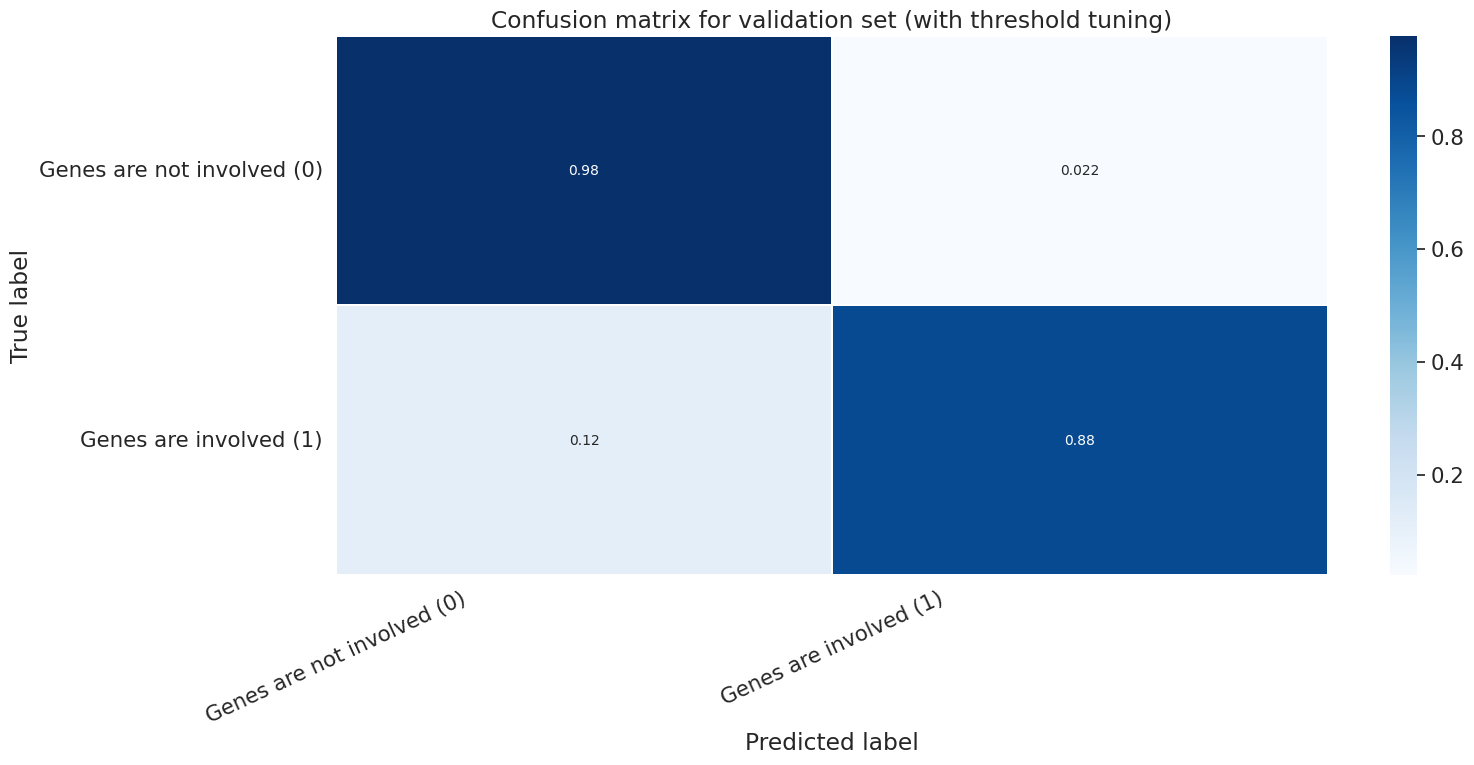

Classification report for validation set with threshold tuning:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2563
           1       0.89      0.88      0.89       520

    accuracy                           0.96      3083
   macro avg       0.93      0.93      0.93      3083
weighted avg       0.96      0.96      0.96      3083

PR AUC score for validation set with threshold tuning:
0.9392
ROC AUC score for validation set with threshold tuning:
0.9755


In [ ]:
# @title With threshold tuning

# Confusion matrix
hold_cm = confusion_matrix(y_test, y_test_predictions)
print(f"Confusion matrix raw scores for validation set:\n{hold_cm}")

# Reshape matrix data for plot
hold_cm = hold_cm.astype('float') / hold_cm.sum(axis=1)[:, np.newaxis]

# Build confusion matrix plot
plt.figure(figsize=(16,7))
sns.set(font_scale=1.4)
sns.heatmap(hold_cm, annot=True, annot_kws={'size':10},
    cmap=plt.cm.Blues, linewidths=0.2)
class_names = ['Genes are not involved (0)', 'Genes are involved (1)']
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix for validation set (with threshold tuning)')

# Display confusion matrix plot
plt.show()

# Classification report
hold_cr = classification_report(y_test, y_test_predictions)
print(f"Classification report for validation set with threshold tuning:\n{hold_cr}")

# Precision area under curve
hold_pr_auc = average_precision_score(y_test, y_test_proba)
print(f"PR AUC score for validation set with threshold tuning:\n{hold_pr_auc:.4f}")

# Receiver operating characteristic area under curve
hold_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"ROC AUC score for validation set with threshold tuning:\n{hold_roc_auc:.4f}")

# model has still only seen validation set once

Confusion matrix raw scores for validation set:
[[2549   14]
 [ 157  363]]


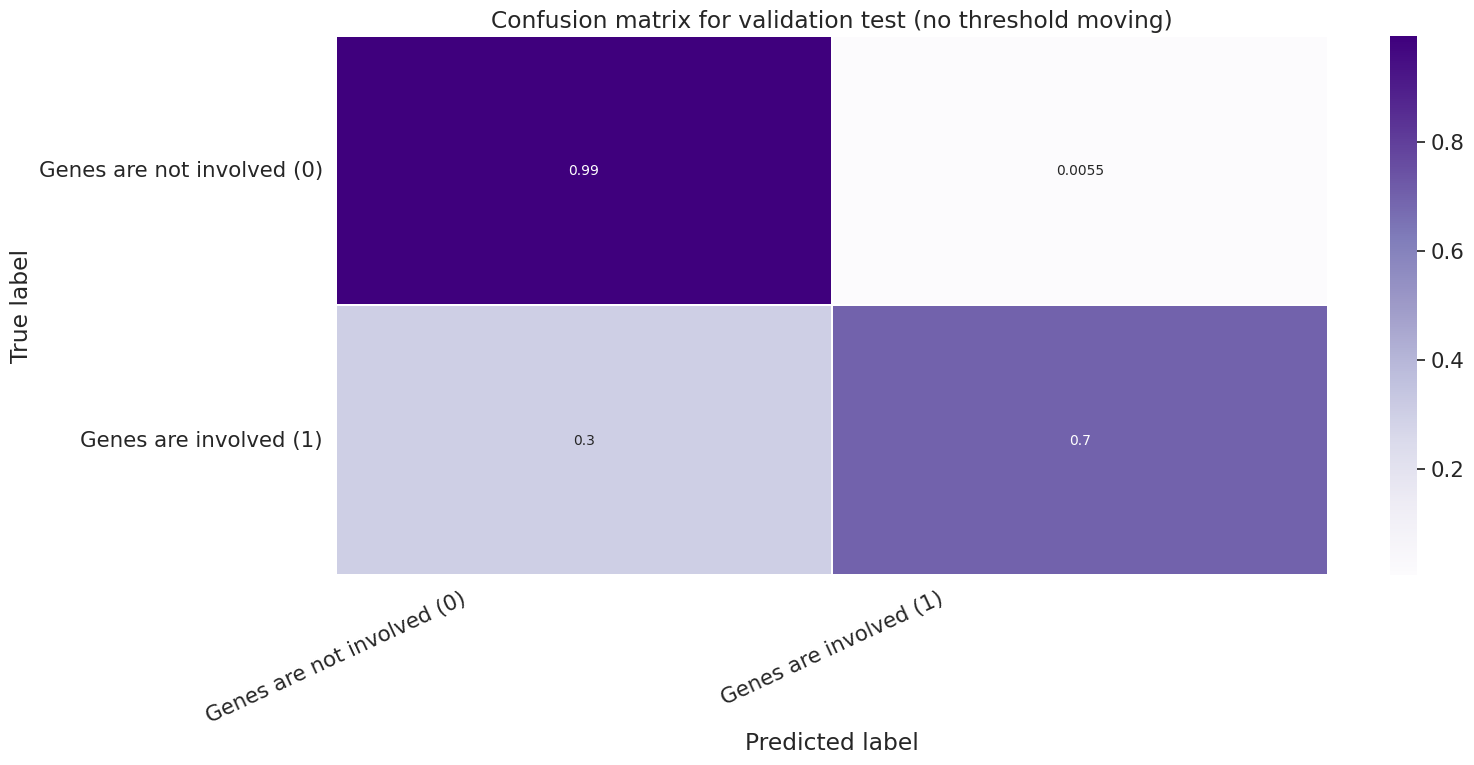

Classification report for validation set without threshold tuning:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2563
           1       0.96      0.70      0.81       520

    accuracy                           0.94      3083
   macro avg       0.95      0.85      0.89      3083
weighted avg       0.95      0.94      0.94      3083

PR AUC score for validation set without threshold tuning:
0.9392
ROC AUC score for validation set without threshold tuning:
0.9755


In [ ]:
# @title Without threshold tuning

# Predict y
y_test_predictions_no = best_model.predict(X_test)

# Predict probabilities of y
y_test_proba_no = best_model.predict_proba(X_test)

# Keep positive outcome probabilities only
y_test_proba_no = y_test_proba_no[:, 1]

# Confusion matrix
hold_cm_no = confusion_matrix(y_test, y_test_predictions_no)
print(f"Confusion matrix raw scores for validation set:\n{hold_cm_no}")

# Reshape matrix data for plot
hold_cm_no = hold_cm_no.astype('float') / hold_cm_no.sum(axis=1)[:, np.newaxis]

# Build confusion matrix plot
plt.figure(figsize=(16,7))
sns.set(font_scale=1.4)
sns.heatmap(hold_cm_no, annot=True, annot_kws={'size':10},
    cmap=plt.cm.Purples, linewidths=0.2)
class_names = ['Genes are not involved (0)', 'Genes are involved (1)']
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix for validation test (no threshold moving)')

# Display confusion matrix plot
plt.show()

# Classification report
hold_cr_no = classification_report(y_test, y_test_predictions_no)
print(f"Classification report for validation set without threshold tuning:\n{hold_cr_no}")

# Precision area under curve
hold_pr_auc_no = average_precision_score(y_test, y_test_proba_no)
print(f"PR AUC score for validation set without threshold tuning:\n{hold_pr_auc_no:.4f}")

# Receiver operating characteristic area under curve
hold_roc_auc_no = roc_auc_score(y_test, y_test_proba_no)
print(f"ROC AUC score for validation set without threshold tuning:\n{hold_roc_auc_no:.4f}")

# model has still only seen validation set once

In [ ]:
# @title Comparison of with/without threshold tuning scores

# Classification report
print(f"\nClassification report with threshold tuning:")
print(hold_cr)
print(f"\nClassification report without threshold tuning:")
print(hold_cr_no)

# PR AUC
print(f"\nPR-AUC with threshold tuning: {hold_pr_auc:.4f}")
print(f"\nPR-AUC without threshold tuning: {hold_pr_auc_no:.4f}")

# ROC AUC
print(f"\nROC-AUC with threshold tuning: {hold_roc_auc:.4f}")
print(f"\nROC-AUC without threshold tuning: {hold_roc_auc_no:.4f}")


Classification report with threshold tuning:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2563
           1       0.89      0.88      0.89       520

    accuracy                           0.96      3083
   macro avg       0.93      0.93      0.93      3083
weighted avg       0.96      0.96      0.96      3083


Classification report without threshold tuning:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2563
           1       0.96      0.70      0.81       520

    accuracy                           0.94      3083
   macro avg       0.95      0.85      0.89      3083
weighted avg       0.95      0.94      0.94      3083


PR-AUC with threshold tuning: 0.9392

PR-AUC without threshold tuning: 0.9392

ROC-AUC with threshold tuning: 0.9755

ROC-AUC without threshold tuning: 0.9755


PR AUC and ROC AUC scores remained the same with or without threshold tuning.

Comparing the confusion matrices, the model is predicting 12% false negatives with threshold tuning. Without threshold tuning, it predicts 30% false negatives. The false positives with threshold tuning increases to 2.2% versus 0.55% without tuning, but true positives rise to 88% from 70% with the threshold decision boundary altered. This rise is accompanied with a 1% drop in true negatives, and overall, the false positive and true negative percentages are an acceptable trade-off.

Vewing the classification reports: the recall is the same as the true positives/negatives as shown in the confusion matrices and already discussed.

The F1 score for the *1* classification improves noticeably with threshold tuning. Precision drops, but this trade-off is also acceptable considering the additional improvement for capturing true positives.

Threshold tuning will be used moving forward.

In [ ]:
# @title Comparison of PR-AUC on training set and validation set

# Training set
print("Training set PR-AUC score:")
print(f"{grid_search.best_score_:.4f}")

# Validation set (threshold tuned)
print("\nValidation set PR-AUC score (threshold tuned):")
print(f"{hold_pr_auc:.4f}")

Training set PR-AUC score:
0.9422

Validation set PR-AUC score (threshold tuned):
0.9392


The PR-AUC scores are similar between the training set and validation set, both quite high and only dropping marginally for the validation set. This suggests the model performs well on hitherto unseen data and is not overfitted.

# **Final model deployment - hidden test**

In [ ]:
# @title Make predictions on hidden test test

# Process hidden test dataset same as training data
X_hidden=test_df.drop(columns=["rep", "sc"]) # sc, rep - features excluded from model

# Sanity check - X_hidden data structure excludes correct features
print("Sanity check - X_hidden data strcture excluding expected features:")
print(X_hidden.head())

# Predict probabilities of y, keep positive outcomes only
y_hidden_proba = best_model.predict_proba(X_hidden)[:, 1]

# Make predictions of y, using the validation set-determined best threshold
y_hidden_predictions = (y_hidden_proba > best_threshold).astype(int)

# model has now seen training set twice, validation set once, hidden test set once

Sanity check - X_hidden data strcture excluding expected features:
       disease  num_genes     emb_0     emb_1     emb_2     emb_3     emb_4  \
ID                                                                            
15411        1      0.008  0.001202 -0.027142 -0.003757  0.019419 -0.002351   
15412        1      0.004 -0.018384 -0.019520  0.009691  0.005816 -0.013052   
15413        1      0.013 -0.007002 -0.005490  0.008867 -0.000167  0.003577   
15414        0      0.011 -0.016772 -0.028181  0.010672 -0.013148 -0.000051   
15415        1      0.004 -0.037281 -0.127243 -0.007415 -0.020436  0.014132   

          emb_5     emb_6     emb_7  ...   emb_502   emb_503   emb_504  \
ID                                   ...                                 
15411  0.001093  0.017700 -0.044377  ... -0.036388  0.006791  0.002623   
15412  0.004658 -0.012587  0.000534  ... -0.014169 -0.000503  0.050537   
15413 -0.005832 -0.027851  0.034867  ... -0.001301 -0.005709  0.005699   
15414 -0.

In [ ]:
# @title Write outputs for uploading to TurnItIn
# Announcement stated naming format is '2712255_BIOLM0050_Individual_Assignment'
test_df = test_df.reset_index() # reset index. ID is column again
df_res_test=test_df[["ID"]].copy() # copy ID to new df
df_res_test["PREDICTION"] = list(y_hidden_predictions) # import hidden test predictions as column into new df
df_res_test.to_csv("2712255_BIOLM0050_Individual_Assignment_ml_results.csv", index=False) # make it a .csv, no index

In [ ]:
# @title Sanity checks
# check there are two columns and the ID starts at 15411
!head -n3 2712255_BIOLM0050_Individual_Assignment_ml_results.csv
# Yes

ID,PREDICTION
15411,0
15412,0


In [ ]:
# Check that there are 1155 predictions
!wc -l 2712255_BIOLM0050_Individual_Assignment_ml_results.csv

1155 2712255_BIOLM0050_Individual_Assignment_ml_results.csv


In [ ]:
# Check the proportion of predictions
!awk -F, 'NR>1 {print $2}' 2712255_BIOLM0050_Individual_Assignment_ml_results.csv | sort | uniq -c

    619 0
    535 1


# **References and resources**

## **References**

[1] [Datasets: Class-imbalanced datasets by Google Developers - Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets)

[2] [What is Feature Selection? by Ivan Belcic and Cole Stryker - IBM](https://www.ibm.com/think/topics/feature-selection)

[3] [1.13. Feature selection - scikit-learn 1.8.0 documentation](https://scikit-learn.org/stable/modules/feature_selection.html)

[4] [An Introduction to Supervised Learning by James Andrew Godwin - Towards Data Science](https://towardsdatascience.com/supervised-learning-61256f2aebeb/)

[5] [Stratified Sampling in Machine Learning - GeeksforGeeks ](https://www.geeksforgeeks.org/machine-learning/stratified-sampling-in-machine-learning/)

[6] [Learning from Imbalanced Classes by Tom Fawcett - Silicon Valley Data Science](http://www.svds.com/learning-imbalanced-classes/)

[7] [Handling Data Imbalance in Machine Learning by O. Olawale Awe, PhD - International Statistical Institute](https://isi-web.org/sites/default/files/2024-02/Handling-Data-Imbalance-in-Machine-Learning.pdf)

[8] [An empirical evaluation of imbalanced data strategies from a practitioner’s point of view by Jacques Wainer - Expert Systems with Applications, 2024](https://www.sciencedirect.com/science/article/abs/pii/S0957417424017305)

[9] [3.1. Cross-validation: evaluating estimator performance - scikit-learn 1.8.0 documentation](https://scikit-learn.org/stable/modules/cross_validation.html)

[10] [Tour of Evaluation Metrics for Imbalanced Classification by Jason Brownlee - Machine Learning Mastery](https://machinelearningmastery.com/tour-of-evaluation-metrics-for-imbalanced-classification/)

[11] [Precision-Recall Curves by Doug Steen - Medium](https://medium.com/@douglaspsteen/precision-recall-curves-d32e5b290248)

[12] [A Gentle Introduction to XGBoost for Applied Machine Learning by Jason Brownlee - Machine Learning Mastery](https://machinelearningmastery.com/gentle-introduction-xgboost-applied-machine-learning/)

[13] [Handling Imbalanced Datasets with XGBoost: Optimizing Model Performance with Smart Parameter Tuning by Mate Voros - Medium](https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf)

[14] ['boosting - how to avoid overfitting in XGBoost model - Stack Exchange'](https://stats.stackexchange.com/questions/443259/how-to-avoid-overfitting-in-xgboost-model)

[15] [A Gentle Introduction to Threshold-Moving for Imbalanced Classification by Jason Brownlee - Machine Learning Mastery](https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/)

[16] [Evaluating a Random Forest model by JR Kreiger - Analytics Vidhya/Medium](https://medium.com/analytics-vidhya/evaluating-a-random-forest-model-9d165595ad56)

## **Resources**

Some code in this notebook was repurposed from available resources on the internet.
Official documentations for scikit-learn and XGBoost were also referred to repeatedly.

**Stratified k fold cross validation for loop:**
[xbeat - 'Machine Learning / Stratified K-Fold Cross-Validation in Python'](https://github.com/xbeat/Machine-Learning/blob/main/Stratified%20K-Fold%20Cross-Validation%20in%20Python.md
)

**scale_pos_weight XGBClassifier:**
[Mate Voros - 'Handling Imbalanced Datasets with XGBoost: Optimizing Model Performance with Smart Parameter Tuning'](https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf
)

**Grid search parameters for XGBClassifier:**
[subsample, colsample_bytree, colsample_bylevel in XGBClassifier() Python 3.x - Stack Overflow](https://stackoverflow.com/questions/51022822/subsample-colsample-bytree-colsample-bylevel-in-xgbclassifier-python-3-x)

**Threshold-tuning:**
[Jason Brownlee - 'A Gentle Introduction to Threshold-Moving for Imbalanced Classification'](https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/)

**Confusion matrix visualisation:**
[JR Kreiger - 'Evaluating a Random Forest model'](https://medium.com/analytics-vidhya/evaluating-a-random-forest-model-9d165595ad56 )

**Workflow structure and general ML concepts:**
 [Dr Mushtaq - 'Supervised (Classification) ML Model Training and Evulation'](https://colab.research.google.com/github/dr-mushtaq/Machine-Learning/blob/master/Supervised_(Classification)_ML_Model_Training_and_Evulation_.ipynb)

  **Convert colab notebooks to PDF:**
 [Convert Google Colab notebook to PDF HTML | Saturn Cloud Blog](https://saturncloud.io/blog/convert-google-colab-notebook-to-pdf-html/)
 [pdf generation - Google Co-laboratory notebook PDF download | stackoverflow](https://stackoverflow.com/questions/52588552/google-co-laboratory-notebook-pdf-download)

 **scikit-learn documentation:**
[scikit-learn 1.3.2 documentation](https://scikit-learn.org/1.3/user_guide.html)

 **xgboost documentation:**
 [xgboost 3.2.0 documentation](https://xgboost.readthedocs.io/en/stable/python/index.htmll)

In [ ]:
# Convert Google Colab notebook to pdf because print to pdf messes this up.
# Even with --quiet this spits out a lot of code.
# FYI - these pages of install code are deleted from the submitted PDF
print("Converting Colab notebook to PDF.")
# Install necessary library
!pip install nbconvert -q -q -q
# Install necessary packages
!apt-get update -q -q -q # Pls work
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc --quiet
# find correct path
#!find /content/drive -name "*.ipynb"
# mount google drive for acess to ipynb files
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!cp "/content/drive/MyDrive/Colab Notebooks/2712255_BIOLM0050_Individual_Assignment_ml_pipeline.ipynb" ./
# Convert colab notebook to pdf format
!jupyter nbconvert --to pdf 2712255_BIOLM0050_Individual_Assignment_ml_pipeline.ipynb
print("Colab notebook conversion to PDF format complete.")

Converting Colab notebook to PDF.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texli